# Imports

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# repo root on path
sys.path.insert(0, str(Path("..").resolve()))
from mvpfn import PFN, BarDistribution, train

In [156]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [157]:
SEQ_LEN = 24
BATCH = 48
STEPS = 400
LR = 3e-3

In [158]:
NUM_FEATURES = 1
NOISE = 0.05
Y_LOW, Y_HIGH = -6.0, 6.0
NUM_BARS = 100

# Prior

In [159]:
def get_batch_regression():
    """Random linear functions."""

    x = torch.rand(SEQ_LEN, BATCH, NUM_FEATURES) * 2 - 1
    w = 0.5 * torch.randn(1, BATCH, NUM_FEATURES)
    b = 0.5 * torch.randn(1, BATCH)
    y = (x * w).sum(-1) + b + NOISE * torch.randn(SEQ_LEN, BATCH)
    
    return x, y

x, y = get_batch_regression()
print("x", x.shape, "y", y.shape)

x torch.Size([24, 48, 1]) y torch.Size([24, 48])


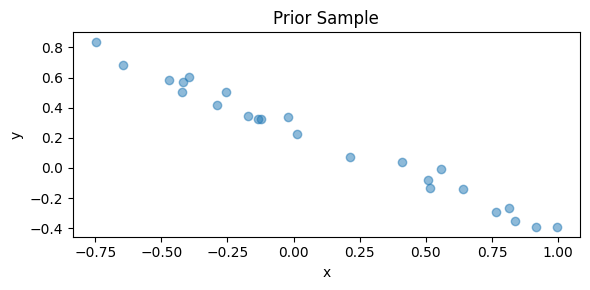

In [160]:
i = 0
plt.figure(figsize=(6, 3))
plt.scatter(x[:, i, 0], y[:, i], alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Prior Sample")
plt.tight_layout()
plt.show()

# Training

In [161]:
criterion_reg = BarDistribution(torch.linspace(Y_LOW, Y_HIGH, NUM_BARS + 1))

model_reg = PFN(
    num_features=NUM_FEATURES,
    n_out=criterion_reg.num_bars,
    d_model=64,
    nhead=4,
    dim_feedforward=128,
    num_layers=3,
)

model_reg = train(model_reg, criterion_reg, get_batch_regression, steps=STEPS, lr=LR, device=device, log_every=100)
model_reg = model_reg.eval()

/Users/noelkronenberg/Documents/GitHub/mv-pfn/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


step 100/400 | loss -0.0730
step 200/400 | loss -0.8150
step 300/400 | loss -0.9488
step 400/400 | loss -0.9858


# Evaluation

In [162]:
with torch.no_grad():
    x, y = get_batch_regression() # new samples
    x, y = x.to(device), y.to(device)
    n_ctx = SEQ_LEN // 2 # context / query split

    logits = model_reg(x[:n_ctx], y[:n_ctx], x[n_ctx:])
    y_query = y[n_ctx:]
    
    pfn_mean = criterion_reg.mean(logits) # predicted mean
    centers = (criterion_reg.borders[:-1] + criterion_reg.borders[1:]) / 2 # bar centers
    probs = torch.softmax(logits, dim=-1) # bar probabilities
    
    pfn_std = (probs * (centers - pfn_mean.unsqueeze(-1)) ** 2).sum(-1).sqrt() # bar std
    mse = ((pfn_mean - y_query) ** 2).mean().item() # MSE
    print(f"MSE: {mse:.4f}")

MSE: 0.0064


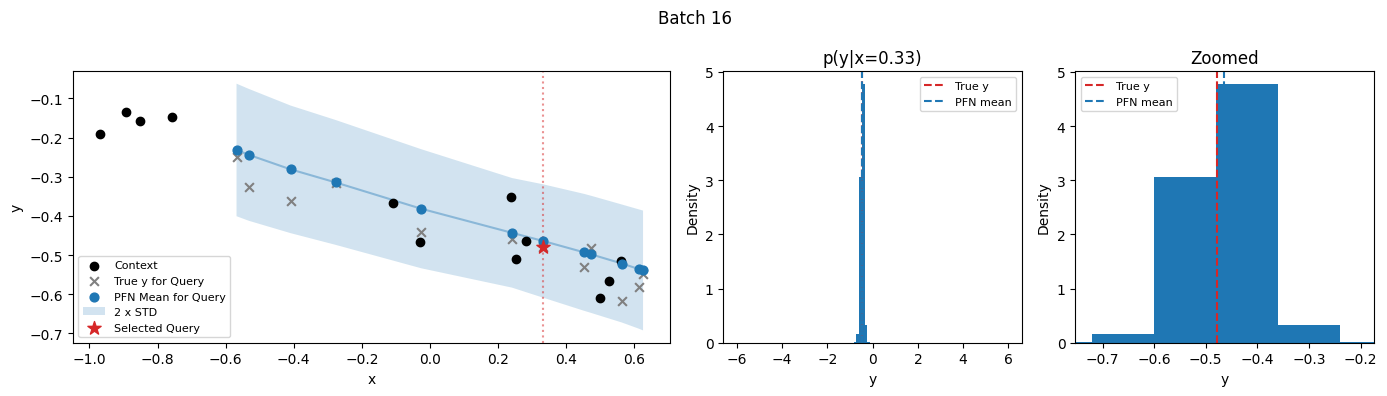

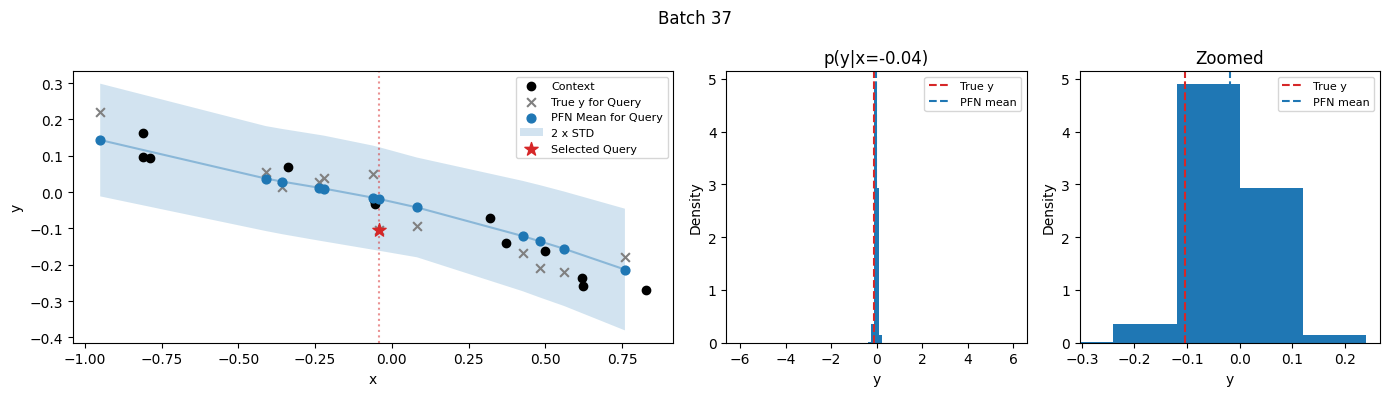

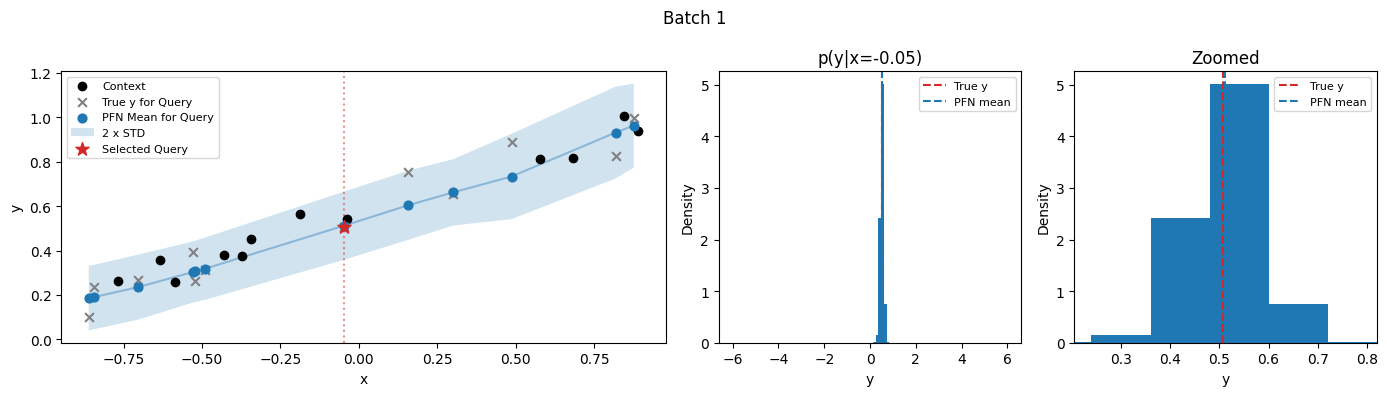

In [163]:
for batch_idx in torch.randperm(BATCH)[:3]:
    xc, yc = x[:n_ctx, batch_idx, 0].cpu(), y[:n_ctx, batch_idx].cpu() # context
    xq = x[n_ctx:, batch_idx, 0].cpu() # query
    yq = y[n_ctx:, batch_idx].cpu() # true y

    pfn = pfn_mean[:, batch_idx].cpu()
    std = pfn_std[:, batch_idx].cpu() 
    order = xq.argsort() # sort for plotting

    qi = order[len(order) // 2] # middle query
    x_sel, y_true = xq[qi], yq[qi] # selected query and true y

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1, 1]})

    ax1.scatter(xc, yc, c="k", label="Context", zorder=3) # context
    ax1.scatter(xq, yq, c="gray", marker="x", s=40, label="True y for Query", zorder=3) # true y
    ax1.scatter(xq, pfn, c="C0", s=40, label="PFN Mean for Query", zorder=4) # PFN mean
    
    ax1.plot(xq[order], pfn[order], c="C0", alpha=0.4) # PFN mean
    ax1.fill_between(xq[order], (pfn - 2 * std)[order], (pfn + 2 * std)[order], alpha=0.2, label="2 x STD") # std (fill)

    ax1.scatter([x_sel], [y_true], c="C3", s=100, marker="*", zorder=5, label="Selected Query") # selected query
    ax1.axvline(x_sel.item(), color="C3", ls=":", alpha=0.5) # vertical line
    
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend(fontsize=8)

    probs = torch.softmax(logits[qi, batch_idx], dim=-1).cpu() # bar probabilities
    borders = criterion_reg.borders.cpu() # bar borders
    widths = borders[1:] - borders[:-1] # bar widths
    density = probs / widths # bar density
    
    # full bar distribution
    ax2.bar(borders[:-1], density, width=widths, align="edge") # bar plot
    ax2.axvline(y_true.item(), color="C3", ls="--", label="True y") # true y
    ax2.axvline(pfn[qi].item(), color="C0", ls="--", label="PFN mean") # PFN mean
    ax2.set_xlabel("y")
    ax2.set_ylabel("Density")
    ax2.set_title(f"p(y|x={x_sel:.2f})")
    ax2.legend(fontsize=8)

    # zoomed bar distribution
    centers = (borders[:-1] + borders[1:]) / 2 # bar centers
    dist_mean = (probs * centers).sum() # distribution mean
    dist_std = (probs * (centers - dist_mean) ** 2).sum().sqrt() # distribution std
    margin = max(4 * dist_std.item(), 0.15) # zoom margin
    ax3.bar(borders[:-1], density, width=widths, align="edge") # bar plot
    ax3.set_xlim(dist_mean - margin, dist_mean + margin) # zoom
    ax3.axvline(y_true.item(), color="C3", ls="--", label="True y") # true y
    ax3.axvline(pfn[qi].item(), color="C0", ls="--", label="PFN mean") # PFN mean
    ax3.set_xlabel("y")
    ax3.set_ylabel("Density")
    ax3.set_title("Zoomed")
    ax3.legend(fontsize=8)

    fig.suptitle(f"Batch {batch_idx}")
    plt.tight_layout()
    plt.show()